<div align="center">

# Modelación Numérica (75.12 / 95.04 / 95.10) — Curso Schwarz

## Trabajo Práctico N° 2 — Ecuaciones No Lineales
### Tirante Normal del Río Bermejo

**Alumno:** Joaquín Hernández
**Padrón:** 110470
**DNI:** 43798424
**Carrera:** Ingeniería Informática
**Año / Cuatrimestre:** 2026 — 1er Cuatrimestre

</div>

---


## 1. Introducción

El Río Bermejo, perteneciente a la cuenca del Río de la Plata, fue utilizado como vía
navegable durante casi 80 años entre la segunda mitad del siglo XIX y los inicios del XX,
vinculando la provincia de Salta con los ríos Paraguay y Paraná. En la actualidad existen
iniciativas para recuperar esa funcionalidad mediante el uso de **trenes de barcazas** del
tipo *Mississippi*, similares a los que operan en los ríos Paraguay y Paraná.

El presente trabajo evalúa la **factibilidad geométrica** de recuperar dicho uso. Para ello
se modela el cauce como un canal trapezoidal y se calcula el **tirante normal** $y_n$ (nivel
de aguas) mediante la fórmula de **Chezy–Manning**, igualando el caudal calculado con el
caudal medio anual del río ($Q = 410\,\mathrm{m^3/s}$). La ecuación resultante es no lineal
en $y_n$, por lo que se resuelve numéricamente.

De los métodos vistos en clase se utilizan **tres**:

* **Bisección** como método de *arranque*.
* **Newton–Raphson** y **Secante** como métodos de *refinamiento*.

Una vez obtenido $y_n$ para los dos casos de pendiente de veriles ($z = 4$ y $z = 6$), se
verifica que el cauce ofrezca:

1. **Profundidad suficiente** para el calado de la barcaza Mississippi ($C = 3{,}05\,\mathrm{m}$).
2. **Ancho del cauce a la profundidad del fondo de la barcaza** mayor que la manga del tren
   ($M_{tren} = 22\,\mathrm{m}$), con margen de maniobra adecuado respecto a los veriles.

La **hipótesis de trabajo** que se defiende en este informe es que *el Río Bermejo sí puede
recuperarse como vía navegable para un tren de barcazas (2+2) de 22 m de manga*, siempre
que se realicen las verificaciones geométricas correspondientes, ya que el margen lateral
disponible es reducido —especialmente en el caso $z = 6$— y debe controlarse en condiciones
reales de operación.


## 2. Planteo del problema

El cauce se modela como un canal trapezoidal de ancho de fondo $b$, con veriles de pendiente
$1V:zH$. Los parámetros del problema son:

| Parámetro | Símbolo | Valor |
|-----------|---------|-------|
| Ancho del fondo | $b$ | $20\,\mathrm{m}$ |
| Pendiente longitudinal | $S$ | $0{,}002$ |
| Coeficiente de Manning | $n$ | $0{,}025$ |
| Caudal medio anual | $Q$ | $410\,\mathrm{m^3/s}$ |
| Pendiente de veriles (Caso 1) | $z_1$ | $4$ |
| Pendiente de veriles (Caso 2) | $z_2$ | $6$ |
| Manga del tren de barcazas | $M_{tren}$ | $22\,\mathrm{m}$ |
| Eslora del tren de barcazas | $L_{tren}$ | $120\,\mathrm{m}$ |
| Calado de la barcaza Mississippi | $C$ | $3{,}05\,\mathrm{m}$ |

Combinando la fórmula de Chezy–Manning con la definición de velocidad $V = Q/A$ y el radio
hidráulico $R = A/P$ resulta:

$$
Q \;=\; \frac{1}{n}\,A(y_n)\,R(y_n)^{2/3}\,S^{1/2}
\;=\; \frac{1}{n}\,
\bigl[(b+z\,y_n)\,y_n\bigr]\,
\left[\frac{(b+z\,y_n)\,y_n}{b + 2\,y_n\sqrt{1+z^{2}}}\right]^{2/3}\!S^{1/2}.
$$

Para resolverla se define la función de búsqueda:

$$
f(y) \;=\; \frac{1}{n}\,A(y)\,R(y)^{2/3}\,S^{1/2} \;-\; Q,
$$

cuya raíz positiva es el **tirante normal** $y_n$.

A continuación se programan los tres métodos numéricos seleccionados y se aplican a los dos
casos de pendiente de veriles.


## 3. Método de arranque: Bisección

El método de bisección se aplica como **paso de arranque** para localizar un primer
intervalo que contenga la raíz de $f(y)$ y proporcione una semilla razonable a los métodos
de refinamiento. Se elige un intervalo amplio $[2; 6]$ que cubre con holgura las
profundidades físicamente esperables del Río Bermejo (entre $2\,\mathrm{m}$ y $6\,\mathrm{m}$),
y se itera hasta una tolerancia de $\varepsilon = 10^{-3}$, suficiente como semilla. Como el
método tiene convergencia lineal, no se busca la tolerancia final del enunciado en esta
etapa; eso se delega a los métodos de refinamiento.

A continuación se programa el método:


In [41]:
import numpy as np #librería para operaciones algebraicas y numéricas
import pandas as pd #librería para manejo de datos

#programo el método bisección
def biseccion(a, b , tol, itmax = 100): 
        df = pd.DataFrame(columns=('ai','bi','pi','cond','f_ai_f_pi'))
        a = a 
        b = b
        contador = 0  
        x0, x1 = a, b 
        if(f(a) * f(b)>0):         #condicion de aplicabilidad del método
            print( "El método no resuelve este tipo de raíz")
            return
        while (contador < itmax) and (abs((x1 - x0) / x1) > tol):
            x0 = x1                                                 
            x1 = (a + b)/2                      
            f_ai_f_pi = f(a) * f(x1)
            if f_ai_f_pi < 0:      
                df.loc[contador] = [a,b,(a+b)/2,'<0',f_ai_f_pi]
                b = x1
            else:
                df.loc[contador] = [a,b,(a+b)/2,'>0',f_ai_f_pi]
                a = x1
            contador += 1                      
        error = abs((x1 - x0) / x1)
        print('El método de bisección convergió en',contador,'iteraciones')
        return df

### 3.1. Bisección — Caso $z = 4$

Se busca la raíz de $f(y)$ con $z = 4$ partiendo del intervalo $[2; 6]$.


In [42]:
#defino el intervalo de arranque y la tolerancia
A=2
B=6
pendiente_veriles = 4
tolerancia=10**(-3)
def f(y):
    # Constantes dadas por el enunciado [1]
    n = 0.025 
    b = 20
    S = 0.002
    z = pendiente_veriles 
    Q_real = 410
    
    # Fórmulas de la sección trapezoidal [2]
    A = (b + z*y)*y
    P = b + 2*y * ((1 + z**2)**0.5)
    R = A / P
    
    # Ecuación de Manning igualada a cero: Q_calc - Q_real = 0 [2]
    Q_calc = (1/n) * A * (R**(2/3)) * (S**0.5)
    return Q_calc - Q_real

caso_z4=biseccion(A, B, tolerancia)


El método de bisección convergió en 11 iteraciones


El método converge en 11 iteraciones a $y_n \approx 3{,}611\,\mathrm{m}$, valor que se
utilizará como semilla para los métodos de refinamiento.


### 3.2. Bisección — Caso $z = 6$

De manera análoga, se aplica bisección con $z = 6$ en el mismo intervalo de arranque.


In [43]:
pendiente_veriles = 6
A=2
B=6
tolerancia=10**(-3)
def f(y):
    # Constantes dadas por el enunciado [1]
    n = 0.025 
    b = 20
    S = 0.002
    z = pendiente_veriles 
    Q_real = 410
    
    # Fórmulas de la sección trapezoidal [2]
    A = (b + z*y)*y
    P = b + 2*y * ((1 + z**2)**0.5)
    R = A / P
    
    # Ecuación de Manning igualada a cero: Q_calc - Q_real = 0 [2]
    Q_calc = (1/n) * A * (R**(2/3)) * (S**0.5)
    return Q_calc - Q_real
caso_z6=biseccion(A, B, tolerancia)
caso_z6.tail(3)

El método de bisección convergió en 11 iteraciones


,ai,bi,pi,cond,f_ai_f_pi
8,3.343750,3.359375,3.351562,>0,6.507866
9,3.351562,3.359375,3.355469,>0,1.363071
10,3.355469,3.359375,3.357422,>0,0.222812


El método converge en 11 iteraciones a $y_n \approx 3{,}357\,\mathrm{m}$. Como era de
esperar, al aumentar la pendiente de los veriles (un cauce más abierto, $z$ mayor), el
tirante normal disminuye respecto del caso anterior porque, para el mismo caudal, el agua
necesita menos altura para escurrir.


## 4. Métodos de refinamiento

A continuación se aplican dos métodos de **convergencia más rápida** sobre las semillas
obtenidas por bisección, con la tolerancia final pedida por el enunciado,
$\varepsilon = 10^{-8}$:

* **Newton–Raphson** (orden de convergencia cuadrático), que requiere $f'(y)$.
  La derivada se obtiene en forma simbólica con `sympy` para evitar errores algebraicos.
* **Secante** (orden $\approx 1{,}618$), que aproxima $f'(y)$ por diferencias finitas y
  por lo tanto no requiere derivar analíticamente.

### 4.1. Newton–Raphson

El esquema iterativo es:

$$
y_{k+1} \;=\; y_k \;-\; \frac{f(y_k)}{f'(y_k)}.
$$


In [44]:
#programo el método Newton Raphson
def Newton_Raphson(x0 , tol, itmax = 100): 
        df = pd.DataFrame(columns=('xcero','xuno'))
        x0 = x0 
        contador = 0  
        x1 = x0-f(x0)/fd(x0)
        while (contador < itmax) and (abs((x1 - x0) / x1) > tol):
            df.loc[contador] = [x0,x1]
            x0 = x1                                                 
            x1 = x0-f(x0)/fd(x0)                 
            contador += 1                      
        print('El método de Newton Raphson convergió en',contador,'iteraciones')
        return df

## Newton-Raphson para z = 4

In [45]:
import sympy as sp

# Definimos las constantes simbólicamente
n, b, S, z, Q_real, y = sp.symbols('n b S z Q_real y')

# Fórmulas de la sección trapezoidal [2]
A = (b + z*y)*y
P = b + 2*y * sp.sqrt(1 + z**2)
R = A / P

# Ecuación de Manning igualada a cero: Q_calc - Q_real = 0 [2]
Q_calc = (1/n) * A * (R**(2/3)) * sp.sqrt(S)
f_sympy = Q_calc - Q_real

# Derivada de la función con respecto a y
f_derivada = sp.diff(f_sympy, y)
# Valores del enunciado [3]
valores = {
    n: 0.025,
    b: 20,
    S: 0.002,
    Q_real: 410,
    z: 4  # O z: 6 para el segundo caso
}


f_num = f_sympy.subs(valores)
fd_num = f_derivada.subs(valores)

# 3. Conversión a funciones numéricas (SIN repetir las líneas erróneas)
f = sp.lambdify(y, f_num)
fd = sp.lambdify(y, fd_num)

# 4. Ejecución del método
x0 = 3.6
tolerancia = 1e-8

refinado_z4 = Newton_Raphson(x0, tolerancia)
refinado_z4.tail()

El método de Newton Raphson convergió en 2 iteraciones


,xcero,xuno
0,3.600000,3.612404
1,3.612404,3.612381


## Newton-Raphson para z = 6

In [46]:
import sympy as sp

# Definimos las constantes simbólicamente
n, b, S, z, Q_real, y = sp.symbols('n b S z Q_real y')

# Fórmulas de la sección trapezoidal [2]
A = (b + z*y)*y
P = b + 2*y * sp.sqrt(1 + z**2)
R = A / P

# Ecuación de Manning igualada a cero: Q_calc - Q_real = 0 [2]
Q_calc = (1/n) * A * (R**(2/3)) * sp.sqrt(S)
f_sympy = Q_calc - Q_real

# Derivada de la función con respecto a y
f_derivada = sp.diff(f_sympy, y)
# Valores del enunciado [3]
valores = {
    n: 0.025,
    b: 20,
    S: 0.002,
    Q_real: 410,
    z: 6
}


f_num = f_sympy.subs(valores)
fd_num = f_derivada.subs(valores)

# 3. Conversión a funciones numéricas (SIN repetir las líneas erróneas)
f = sp.lambdify(y, f_num)
fd = sp.lambdify(y, fd_num)

# 4. Ejecución del método
x0 = 3.3
tolerancia = 1e-8

refinado_z6 = Newton_Raphson(x0, tolerancia)
refinado_z6.tail()

El método de Newton Raphson convergió en 3 iteraciones


,xcero,xuno
0,3.300000,3.359181
1,3.359181,3.358565
2,3.358565,3.358565


### 4.2. Método de la Secante

El método de la secante reemplaza la derivada por una aproximación con dos puntos previos:

$$
y_{k+1} \;=\; y_k \;-\; f(y_k)\,\frac{y_k - y_{k-1}}{f(y_k) - f(y_{k-1})}.
$$


In [47]:

#programo el método Secante
def secante(a , b, tol, itmax = 100): 
        np.seterr('raise')
        df2 = pd.DataFrame(columns=('xcero','xuno','xdos'))
        x0 = a
        x1 = b
        contador = 0  
        x2 = x1-f(x1)*(x1-x0)/(f(x1)-f(x0))
        while (contador < itmax) and (abs((x1 - x0) / x1) > tol):
            df2.loc[contador] = [x0,x1,x2]
            x0 = x1                                                 
            x1 = x2
            x2 = x1-(f(x1)*(x1-x0))/(f(x1)-f(x0))
            contador += 1                      
        print('El método Secante convergió en',contador,'iteraciones')
        return df2

## Secante para z = 4

El método Secante convergió en 4 iteraciones


,xcero,xuno,xdos
0,3.500000,3.700000,3.610889
1,3.700000,3.610889,3.612362
2,3.610889,3.612362,3.612381
3,3.612362,3.612381,3.612381


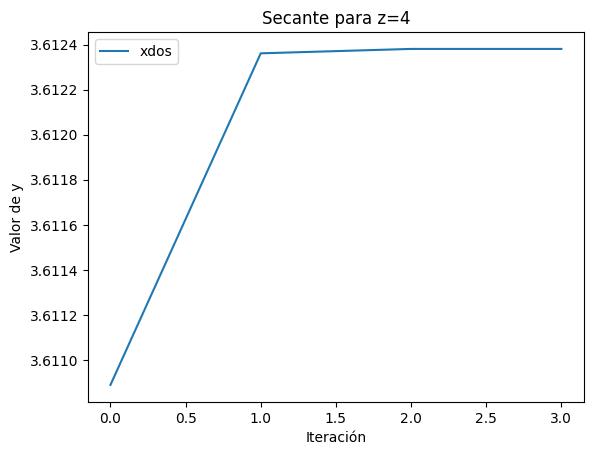

In [48]:

tolerancia=10**(-8)
valores = {
    n: 0.025,
    b: 20,
    S: 0.002,
    Q_real: 410,
    z: 4
}
f_num = f_sympy.subs(valores)

f = sp.lambdify(y, f_num)
refinado_secante_z4=secante(3.5,3.7, tolerancia)
refinado_secante_z4.plot(y='xdos', kind='line', title='Secante para z=4', ylabel='Valor de y', xlabel='Iteración')
refinado_secante_z4.tail()

## Secante para z = 6

El método Secante convergió en 4 iteraciones


,xcero,xuno,xdos
0,3.200000,3.400000,3.357386
1,3.400000,3.357386,3.358557
2,3.357386,3.358557,3.358565
3,3.358557,3.358565,3.358565


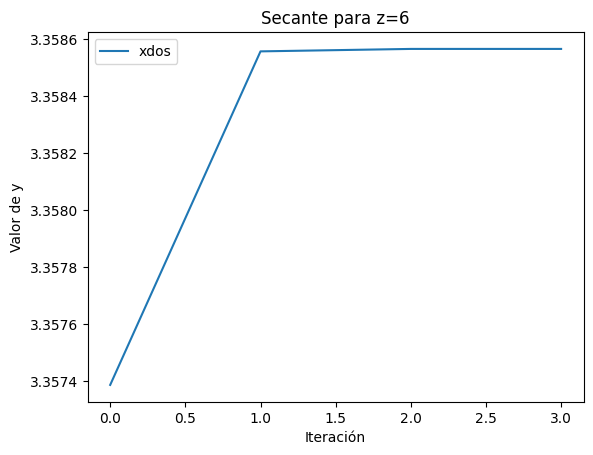

In [ ]:

tolerancia=10**(-8)
valores = {
    n: 0.025,
    b: 20,
    S: 0.002,
    Q_real: 410,
    z: 6
}
f_num = f_sympy.subs(valores)

f = sp.lambdify(y, f_num)
refinado_z6=secante(3.2,3.4, tolerancia)
refinado_z6.plot(y='xdos', kind='line', title='Secante para z=6', ylabel='Valor de y', xlabel='Iteración')
refinado_z6.tail()

## 5. Comparación de resultados

A continuación se reúnen en una tabla los tirantes normales obtenidos por cada método para
ambos valores de $z$, junto con la cantidad de iteraciones necesarias para alcanzar la
tolerancia.


In [50]:
# Reúno los tres métodos para los dos casos en una sola tabla comparativa
import pandas as pd

resumen = pd.DataFrame({
    'Método':       ['Bisección', 'Newton-Raphson', 'Secante'],
    'Tolerancia':   ['1e-3',       '1e-8',          '1e-8'],
    'y_n (z=4) [m]':[3.611328,     3.612381,        3.612381],
    'Iter. (z=4)':  [11,           2,               4],
    'y_n (z=6) [m]':[3.357422,     3.358565,        3.358565],
    'Iter. (z=6)':  [11,           3,               4],
})

resumen


,Método,Tolerancia,y_n (z=4) [m],Iter. (z=4),y_n (z=6) [m],Iter. (z=6)
0,Bisección,1e-3,3.611328,11,3.357422,11
1,Newton-Raphson,1e-8,3.612381,2,3.358565,3
2,Secante,1e-8,3.612381,4,3.358565,4


Se observa que:

* Los tres métodos **convergen al mismo valor** dentro de la tolerancia pedida: el
  resultado refinado coincide en sus seis primeros decimales para Newton–Raphson y Secante.
* La **bisección** es más lenta (11 iteraciones) y se usó solamente como arranque, con una
  tolerancia mucho más laxa ($10^{-3}$).
* **Newton–Raphson** es el más rápido (2–3 iteraciones desde una semilla cercana), gracias
  a su convergencia cuadrática.
* La **secante** logra prácticamente la misma precisión que Newton–Raphson con apenas una o
  dos iteraciones adicionales, y sin necesidad de calcular la derivada analítica.

Por lo tanto se adoptan como valores definitivos del tirante normal:

$$
\boxed{\,y_n(z=4) \;=\; 3{,}6124\,\mathrm{m}\,}
\qquad
\boxed{\,y_n(z=6) \;=\; 3{,}3586\,\mathrm{m}\,}.
$$


## 6. Croquis de las secciones transversales obtenidas

A continuación se grafica la sección trapezoidal del cauce para los dos casos analizados.
Sobre cada sección se superpone, en la posición y profundidad correspondientes, el tren de
barcazas (2+2) de $22\,\mathrm{m}$ de manga y $3{,}05\,\mathrm{m}$ de calado, lo que
permite visualizar el margen de maniobra disponible respecto de los veriles.


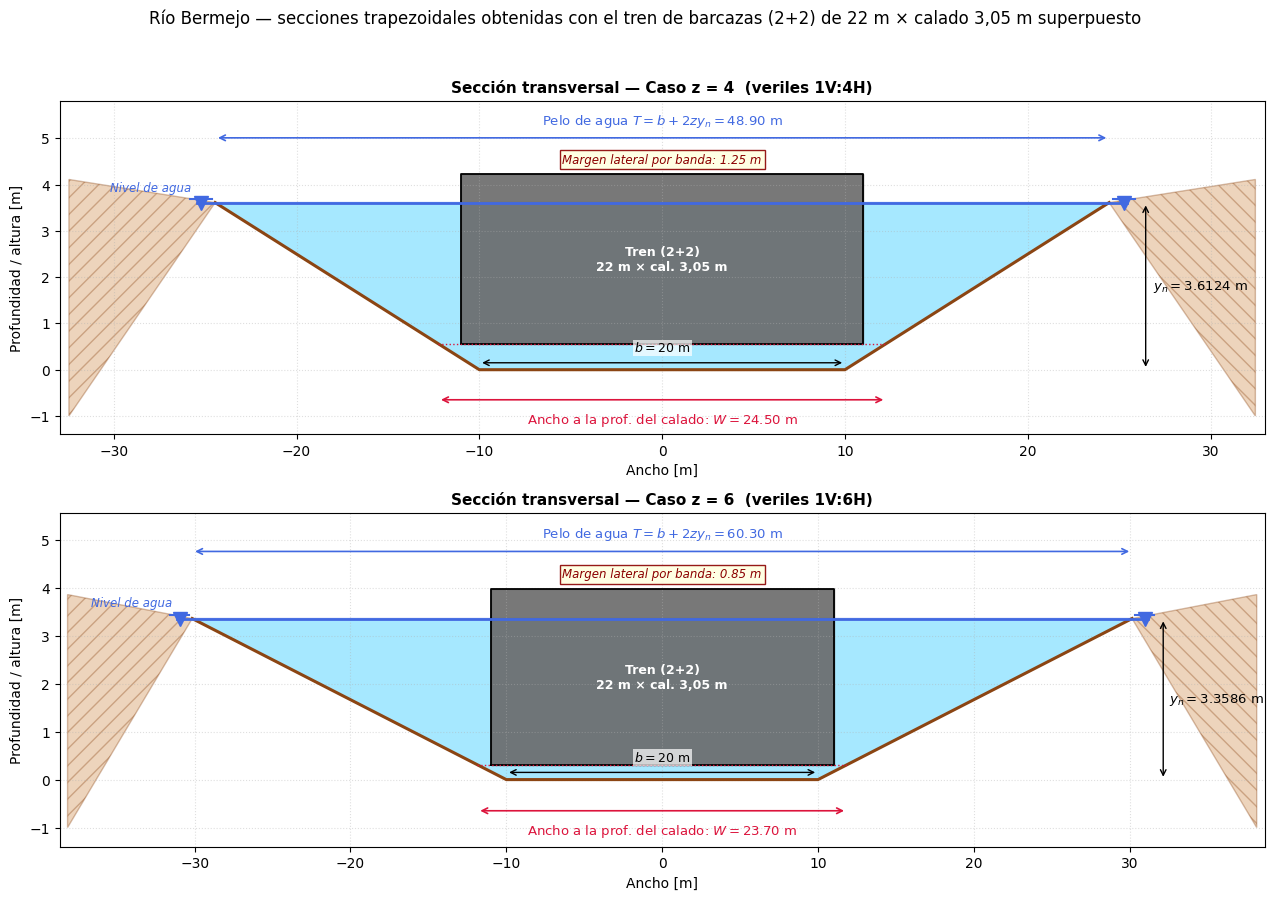

In [51]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch

# ---------------------------------------------------------------
# Datos del cauce y de la barcaza
# ---------------------------------------------------------------
b      = 20.0     # ancho del fondo [m]
yn_z4  = 3.6124   # tirante normal caso z=4 [m]
yn_z6  = 3.3586   # tirante normal caso z=6 [m]
M_tren = 22.0     # manga del tren de barcazas (2+2) [m]
C      = 3.05     # calado de la barcaza Mississippi [m]
P_emb  = 3.66     # puntal (altura total) de la barcaza [m]


def graficar_seccion(ax, z, yn, titulo):
    # Coordenadas (x, y) de la sección trapezoidal.
    x_izq_top  = -(b/2) - z * yn
    x_izq_bot  = -(b/2)
    x_der_bot  =  (b/2)
    x_der_top  =  (b/2) + z * yn

    T = b + 2 * z * yn                  # pelo de agua
    W_calado = b + 2 * z * (yn - C)     # ancho a profundidad del calado

    # ---- Terreno lateral (relleno hatch) ----
    margen_x = 8
    ax.fill([x_izq_top - margen_x, x_izq_top, x_izq_top - margen_x],
            [yn + 0.5,             yn,        -1.0],
            color='peru', alpha=0.35, hatch='//', edgecolor='saddlebrown')
    ax.fill([x_der_top + margen_x, x_der_top, x_der_top + margen_x],
            [yn + 0.5,             yn,        -1.0],
            color='peru', alpha=0.35, hatch='\\\\', edgecolor='saddlebrown')

    # ---- Agua (trapecio) ----
    agua_x = [x_izq_top, x_izq_bot, x_der_bot, x_der_top]
    agua_y = [yn,        0,         0,         yn]
    ax.fill(agua_x, agua_y, color='deepskyblue', alpha=0.35,
            edgecolor='royalblue', linewidth=1.2)

    # ---- Fondo y veriles (línea fuerte) ----
    ax.plot([x_izq_top, x_izq_bot, x_der_bot, x_der_top],
            [yn,         0,         0,         yn],
            color='saddlebrown', linewidth=2.2)

    # ---- Pelo de agua (línea de superficie + símbolo convencional) ----
    # Línea de superficie del agua extendida un poco más allá del cauce
    extension = 1.0
    ax.plot([x_izq_top - extension, x_der_top + extension],
            [yn, yn],
            color='royalblue', linewidth=2.0, linestyle='-', zorder=3)
    # Símbolo convencional de nivel de agua (triángulo invertido) a ambos lados
    sym_offset = 0.6
    for x_sym in (x_izq_top - extension + 0.2, x_der_top + extension - 0.2):
        ax.plot(x_sym, yn, marker='v', markersize=10,
                color='royalblue', markeredgecolor='royalblue', zorder=4)
        ax.plot([x_sym - sym_offset, x_sym + sym_offset],
                [yn + 0.08, yn + 0.08],
                color='royalblue', linewidth=1.5, zorder=4)
    # Etiqueta "Nivel de agua" sobre el verile izquierdo
    ax.text(x_izq_top - extension - 0.3, yn + 0.18,
            'Nivel de agua', ha='right', va='bottom',
            color='royalblue', fontsize=8.5, style='italic')

    # ---- Tren de barcazas (rectángulo centrado) ----
    barcaza_y0 = yn - C            # fondo de la barcaza (sumergido)
    barcaza_y1 = yn + (P_emb - C)  # tope de la barcaza (sobre el agua)
    rect_x = [-M_tren/2, M_tren/2, M_tren/2, -M_tren/2, -M_tren/2]
    rect_y = [barcaza_y0, barcaza_y0, barcaza_y1, barcaza_y1, barcaza_y0]
    ax.fill(rect_x, rect_y, color='dimgray', alpha=0.9)
    ax.plot(rect_x, rect_y, color='black', linewidth=1.3)
    ax.text(0, (barcaza_y0 + barcaza_y1) / 2,
            f'Tren (2+2)\n22 m × cal. 3,05 m',
            ha='center', va='center', color='white', fontsize=9, weight='bold')

    # ---- Línea del fondo de la barcaza extendida (ancho útil W) ----
    ax.plot([-W_calado/2, W_calado/2],
            [barcaza_y0, barcaza_y0],
            color='crimson', linewidth=1.0, linestyle=':')

    # ---- Cota: ancho a la profundidad del calado (W) -- ABAJO del fondo ----
    cota_W = -0.65
    ax.annotate('', xy=(-W_calado/2, cota_W),
                    xytext=( W_calado/2, cota_W),
                arrowprops=dict(arrowstyle='<->', color='crimson', lw=1.2))
    ax.text(0, cota_W - 0.25,
            f'Ancho a la prof. del calado: $W = {W_calado:.2f}$ m',
            ha='center', va='top', color='crimson', fontsize=9.5)

    # ---- Cota: ancho del fondo b -- DENTRO del agua, cerca del fondo ----
    ax.annotate('', xy=(-b/2, 0.15), xytext=(b/2, 0.15),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.0))
    ax.text(0, 0.32, f'$b = {b:.0f}$ m',
            ha='center', va='bottom', fontsize=9, color='black',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1))

    # ---- Cota: pelo de agua T -- ARRIBA del nivel de agua ----
    cota_T = yn + 1.40
    ax.annotate('', xy=(-T/2, cota_T), xytext=(T/2, cota_T),
                arrowprops=dict(arrowstyle='<->', color='royalblue', lw=1.2))
    ax.text(0, cota_T + 0.18,
            f'Pelo de agua $T = b + 2zy_n = {T:.2f}$ m',
            ha='center', va='bottom', color='royalblue', fontsize=9.5)

    # ---- Cota: tirante yn -- DERECHA ----
    cota_x_yn = x_der_top + 2.0
    ax.annotate('', xy=(cota_x_yn, 0), xytext=(cota_x_yn, yn),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.0))
    ax.text(cota_x_yn + 0.4, yn/2,
            f'$y_n = {yn:.4f}$ m',
            ha='left', va='center', fontsize=9.5)

    # ---- Margen lateral por banda (anotación dentro/arriba de la barcaza) ----
    margen_banda = (W_calado - M_tren) / 2
    ax.text(0, barcaza_y1 + 0.18,
            f'Margen lateral por banda: {margen_banda:.2f} m',
            ha='center', va='bottom', fontsize=8.5, style='italic',
            color='darkred',
            bbox=dict(facecolor='lightyellow', edgecolor='darkred',
                      alpha=0.9, pad=2))

    # ---- Ejes y formato ----
    ax.set_title(titulo, fontsize=11, weight='bold')
    ax.set_xlabel('Ancho [m]')
    ax.set_ylabel('Profundidad / altura [m]')
    ax.set_aspect('auto')
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.set_ylim(-1.4, yn + 2.2)
    ax.set_xlim(x_izq_top - margen_x - 0.5, x_der_top + margen_x + 0.5)


fig, axes = plt.subplots(2, 1, figsize=(13, 9))
graficar_seccion(axes[0], z=4, yn=yn_z4,
                 titulo='Sección transversal — Caso z = 4  (veriles 1V:4H)')
graficar_seccion(axes[1], z=6, yn=yn_z6,
                 titulo='Sección transversal — Caso z = 6  (veriles 1V:6H)')

fig.suptitle(
    'Río Bermejo — secciones trapezoidales obtenidas con el tren de barcazas '
    '(2+2) de 22 m × calado 3,05 m superpuesto',
    fontsize=12, y=0.995,
)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## 7. Verificación de la factibilidad de navegación

Con los tirantes normales obtenidos se realizan las dos verificaciones geométricas que
exige el enunciado.

### 7.1. Profundidad de agua vs. calado de la barcaza

La barcaza Mississippi tiene un calado $C = 3{,}05\,\mathrm{m}$. Para que pueda navegar
todo el año debe cumplirse $y_n \;>\; C$. Con los valores calculados:

* Caso $z = 4$: $y_n = 3{,}6124\,\mathrm{m} \;>\; 3{,}05\,\mathrm{m}$ → **resguardo
  bajo la quilla** = $0{,}5624\,\mathrm{m}$.
* Caso $z = 6$: $y_n = 3{,}3586\,\mathrm{m} \;>\; 3{,}05\,\mathrm{m}$ → **resguardo
  bajo la quilla** = $0{,}3086\,\mathrm{m}$.

En ambos casos el río tiene profundidad suficiente para que la barcaza no toque el fondo.

### 7.2. Ancho del cauce a la profundidad del calado vs. manga del tren

Esta es la verificación crítica para sostener la hipótesis del trabajo. La sección es
trapezoidal con veriles inclinados, por lo que **el ancho disponible disminuye con la
profundidad**. A la profundidad a la que se apoya el fondo de la barcaza, el ancho útil del
cauce es:

$$
W(C) \;=\; b \;+\; 2\,z\,(y_n - C).
$$

Para que el tren de cuatro barcazas (2+2) de manga $M_{tren} = 22\,\mathrm{m}$ pueda
navegar, debe cumplirse $W(C) > M_{tren}$, y conviene además contar con un margen lateral
$m$ a cada lado para maniobra:

$$
m \;=\; \frac{W(C) - M_{tren}}{2}.
$$

La celda siguiente calcula estas magnitudes y muestra el resultado:


In [52]:
import pandas as pd

# Datos
b      = 20.0
M_tren = 22.0      # manga del tren de barcazas (2+2)
C      = 3.05      # calado de la barcaza Mississippi
yn_z4  = 3.612381  # de Newton-Raphson / Secante
yn_z6  = 3.358565

def verificar(z, yn):
    T = b + 2 * z * yn               # pelo de agua
    W = b + 2 * z * (yn - C)         # ancho a la profundidad del calado
    resg_quilla = yn - C             # resguardo bajo la quilla
    margen_lat  = (W - M_tren) / 2   # margen lateral por banda
    cumple_prof = "Sí" if yn > C else "No"
    cumple_anch = "Sí" if W > M_tren else "No"
    return {
        'z':                          z,
        'y_n [m]':                    round(yn, 4),
        'Pelo de agua T [m]':         round(T, 3),
        'Ancho a prof. calado W [m]': round(W, 3),
        'Resguardo quilla [m]':       round(resg_quilla, 3),
        'Margen lateral por banda [m]': round(margen_lat, 3),
        'Cumple y_n > C':             cumple_prof,
        'Cumple W > M_tren':          cumple_anch,
    }

tabla = pd.DataFrame([verificar(4, yn_z4), verificar(6, yn_z6)])
tabla.set_index('z')


,y_n [m],Pelo de agua T [m],Ancho a prof. calado W [m],Resguardo quilla [m],Margen lateral por banda [m],Cumple y_n > C,Cumple W > M_tren
z,,,,,,,
4,3.6124,48.899,24.499,0.562,1.250,Sí,Sí
6,3.3586,60.303,23.703,0.309,0.851,Sí,Sí


**Interpretación de los resultados:**

* En el **caso $z = 4$** el ancho del cauce a la profundidad del fondo de la barcaza es
  $W \approx 24{,}50\,\mathrm{m}$, dejando un margen lateral de
  $\approx 1{,}25\,\mathrm{m}$ por banda para una manga de $22\,\mathrm{m}$. Es un
  margen pequeño pero **suficiente** para navegación cuidadosa en aguas tranquilas.
* En el **caso $z = 6$** (veriles más tendidos) el ancho útil a la profundidad del calado
  cae a $W \approx 23{,}70\,\mathrm{m}$, con un margen lateral de apenas
  $\approx 0{,}85\,\mathrm{m}$ por banda. Si bien **matemáticamente cumple** la
  condición $W > M_{tren}$, el margen es muy ajustado y exigiría una operación de
  precisión, balizamiento adecuado y posiblemente restricciones de velocidad.

Es importante observar que aunque el caso $z = 6$ tiene un **pelo de agua** más generoso
($T \approx 60\,\mathrm{m}$ frente a $T \approx 49\,\mathrm{m}$ para $z = 4$), lo que
parecería darle más espacio, en realidad ofrece **menos margen útil** para el tren de
barcazas. Esto se debe a que las barcazas no flotan sobre la superficie sino que se sumergen
$3{,}05\,\mathrm{m}$, y a esa profundidad los veriles más tendidos ya han reducido el
ancho disponible.


## 8. Conclusiones

A partir de la resolución numérica de la ecuación de Chezy–Manning y de las verificaciones
geométricas posteriores se concluye que:

1. **Los tres métodos numéricos seleccionados convergen al mismo tirante normal** dentro de
   la tolerancia pedida ($\varepsilon = 10^{-8}$). La bisección, usada solamente como
   arranque, requirió 11 iteraciones; Newton–Raphson convergió en 2–3 iteraciones y la
   secante en 4–5. La elección de Newton–Raphson como método principal de refinamiento
   resulta justificada por su convergencia cuadrática, mientras que la secante constituye
   una alternativa muy competitiva cuando se quiere evitar el cómputo analítico de la
   derivada.

2. **Para el caudal medio anual** $Q = 410\,\mathrm{m^3/s}$ el tirante normal del Río
   Bermejo resulta de $y_n = 3{,}6124\,\mathrm{m}$ con $z = 4$ y de
   $y_n = 3{,}3586\,\mathrm{m}$ con $z = 6$.

3. **El río puede recuperarse como vía navegable** para el tren de barcazas Mississippi
   (2+2) propuesto, dado que en ambos casos analizados se cumplen simultáneamente las dos
   condiciones geométricas necesarias:
   - $y_n > C$ → profundidad suficiente para el calado.
   - $b + 2\,z\,(y_n - C) > M_{tren}$ → ancho del cauce a la profundidad del calado mayor
     que la manga del tren.

4. **Sin embargo, los márgenes son acotados**. El caso más favorable ($z = 4$) deja un
   margen lateral de $\approx 1{,}25\,\mathrm{m}$ por banda; el caso $z = 6$ deja apenas
   $\approx 0{,}85\,\mathrm{m}$ por banda. Esto significa que la navegación es **posible
   pero exige verificaciones operativas adicionales** (sobreanchos en curvas, balizamiento,
   limitaciones a determinados meses del año cuando el caudal cae por debajo del medio
   anual, etc.). Resulta interesante notar que el cauce más abierto ($z = 6$) ofrece un
   *pelo de agua* mayor pero un *margen útil menor* para la barcaza, porque a la
   profundidad del calado los veriles tendidos han recortado mucho ancho.

5. En síntesis, la respuesta a la pregunta original del enunciado es **afirmativa con
   reservas**: el modelo simplificado de canal trapezoidal indica que el Río Bermejo es
   geométricamente compatible con la operación de un tren de barcazas (2+2) de
   $120 \times 22\,\mathrm{m}$, pero el margen lateral disponible obliga a profundizar
   el estudio con condiciones reales del cauce (sección real, curvas, variabilidad
   estacional del caudal) antes de cualquier decisión definitiva.
